<font size=6>实验3：循环神经网络</font>

# 实验简介

本实验介绍利用PyTorch构建循环神经网络的方法。我们将构建一个姓名的分类模型，也就是根据姓名的英文拼写，预测姓名来自哪种语言（例如"Hinton"是苏格兰语姓氏，"Schmidhuber"是德语姓氏）。通过本实验，你将掌握以下技能：

- 手工创建循环神经网络
- 构建基于循环神经网络的分类模型
- 基础的英文文本数据处理技巧

# 实验环境准备

首先，你需要安装完成本实验所需的必要组件。

## 安装Miniconda

从以下链接下载Miniconda安装包并完成安装[[Link]](https://mirrors.tuna.tsinghua.edu.cn/anaconda/miniconda/Miniconda3-py310_24.1.2-0-Windows-x86_64.exe)，安装过程中需要选中`Register Anaconda as my default Python 3.10`。若计算机上已经安装好Miniconda或Anaconda，请跳过此步骤。

## 安装Jupyter Notebook

在Anaconda Prompt中执行`pip install notebook`，以安装Jupyter Notebook。

安装完成后，在Anaconda Prompt执行`jupyter notebook`，检查是否能够成功启动Notebook。

若计算机上已经安装好Jupyter Notebook，请跳过此步骤。

## 安装必要的Package

你可以使用以下代码在Jupyter Notebook中检查并安装必要的包，也可事先在Anaconda Prompt中通过`pip`或`conda`安装好。

In [1]:
from importlib.util import find_spec

# 检查PyTorch是否已安装
if find_spec('torch').loader:
    print('PyTorch is available.')
else:
    !pip install torch -i https://pypi.tuna.tsinghua.edu.cn/simple/  # 安装PyTorch最新的CPU稳定版本

PyTorch is available.


如果你希望安装GPU版本，请参阅[[Link]](https://pytorch.org/get-started/locally/)。

# 数据准备

点击以下链接下载本实验用到的数据集：

[[Link]](https://download.pytorch.org/tutorial/data.zip)

将数据集下载并解压到当前Notebook所在的目录。在`data/names`目录下，包含了18个文本文件（`[Language].txt`），每个文件都包含了来源于文件名所示语言的一系列姓氏。然而，其中有少部分人名使用的是非拉丁字母拼写，我们需要进行转换。

In [2]:
# 防止可能的kmp_duplicate_lib_ok错误
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [3]:
# 首先，不妨查看数据集中包含的文件
from io import open
import glob

def findFiles(path): return glob.glob(path)

print(findFiles('data/names/*.txt'))

['data/names\\Arabic.txt', 'data/names\\Chinese.txt', 'data/names\\Czech.txt', 'data/names\\Dutch.txt', 'data/names\\English.txt', 'data/names\\French.txt', 'data/names\\German.txt', 'data/names\\Greek.txt', 'data/names\\Irish.txt', 'data/names\\Italian.txt', 'data/names\\Japanese.txt', 'data/names\\Korean.txt', 'data/names\\Polish.txt', 'data/names\\Portuguese.txt', 'data/names\\Russian.txt', 'data/names\\Scottish.txt', 'data/names\\Spanish.txt', 'data/names\\Vietnamese.txt']


这里，我们需要对数据进行初步处理。

In [4]:
import unicodedata
import string

all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)

def unicodeToAscii(s):
    '''
    将带附加符号的字母转为普通拉丁字母
    '''
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )

print(unicodeToAscii('Ślusàrski'))

Slusarski


In [5]:
# 创建Dict，用于存放所有类别及所包含的人名
category_lines = {}
all_categories = []

def readLines(filename):
    '''
    读取文件并存放到列表
    '''
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    return [unicodeToAscii(line) for line in lines]

# 处理所有文本文件，完成数据读取和规整
for filename in findFiles('data/names/*.txt'):
    category = os.path.splitext(os.path.basename(filename))[0]
    all_categories.append(category)
    lines = readLines(filename)
    category_lines[category] = lines

n_categories = len(all_categories)

这里，我们检查`category_lines`中的数据是否符合预期。

In [6]:
print(category_lines['Italian'][:5])

['Abandonato', 'Abatangelo', 'Abatantuono', 'Abate', 'Abategiovanni']


# 将人名转换为张量

在处理文本时，通常不能直接使用字母作为输入。本实验中，我们采用一种简单的策略，即通过One-hot编码表示每个字符，由于人名中可能出现的字符（大写、小写及连字符等少数其他字符）仅有57个，所以每个字符对应的One-hot编码向量元素个数为57。

In [7]:
import torch

# 查找字符的序号，例如"a" = 0
def letterToIndex(letter):
    return all_letters.find(letter)

# 将字符转为 <1 x n_letters> 张量，n_letters=57
def letterToTensor(letter):
    tensor = torch.zeros(1, n_letters)
    tensor[0][letterToIndex(letter)] = 1
    return tensor

# 将人名转为 <character_num x 1 x n_letters> 张量，n_letters=57
def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor

print(letterToTensor('J'))
print(lineToTensor('Jones').size())

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.]])
torch.Size([5, 1, 57])


# 创建循环神经网络

手工创建一个简单的RNN模型，该模型包含2个线性层，并对输出进行`LogSoftmax`操作，得到分类结果。

In [8]:
import torch.nn as nn

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.i2h = nn.Linear(input_size + hidden_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        combined = torch.cat((input, hidden), 1)
        hidden = self.i2h(combined)
        output = self.h2o(hidden)
        output = self.softmax(output)
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, self.hidden_size)

n_hidden = 128
rnn = RNN(n_letters, n_hidden, n_categories)  # 实例化模型

我们不妨进行一次前向计算测试，观察输出是否符合预期。

In [9]:
input = lineToTensor('Albert')
hidden = torch.zeros(1, n_hidden)
output, next_hidden = rnn(input[0], hidden)
print(output)

tensor([[-2.7861, -2.8724, -2.8615, -2.8805, -2.9798, -2.8938, -2.8985, -2.9280,
         -2.8314, -2.8751, -2.8734, -2.9656, -2.8669, -2.9123, -2.8710, -2.9182,
         -2.9437, -2.8867]], grad_fn=<LogSoftmaxBackward0>)


可以看到，模型输出是一个 <1 × 18> 的张量，每个元素代表属于当前类别的似然，越大代表越可能属于该类。

# 模型训练

首先，我们定义一些辅助函数，帮助我们完成后续训练和测试任务。

为了将输出映射到特定类别，定义`categoryFromOutput`函数如下。

In [13]:
def categoryFromOutput(output):
    top_n, top_i = output.topk(1)
    category_i = top_i[0].item()
    return all_categories[category_i], category_i

print(categoryFromOutput(output))

('Arabic', 0)


接下来，为了方便载入一组训练数据，定义`randomTrainingExample`函数。

In [14]:
import random

def randomChoice(l):
    return l[random.randint(0, len(l) - 1)]

def randomTrainingExample():
    category = randomChoice(all_categories)
    line = randomChoice(category_lines[category])
    category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long)
    line_tensor = lineToTensor(line)
    return category, line, category_tensor, line_tensor

for i in range(10):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    print('category =', category, '/ line =', line)

category = English / line = Ostler
category = Spanish / line = Escamilla
category = Dutch / line = Oorschot
category = Polish / line = Warszawski
category = Italian / line = Guidi
category = French / line = Roche
category = Polish / line = Kaczka
category = Italian / line = Nisi
category = Japanese / line = Mitsukuri
category = French / line = Bellerose


定义训练函数如下。

In [15]:
criterion = nn.NLLLoss()
learning_rate = 0.005

def train(category_tensor, line_tensor):
    hidden = rnn.initHidden()
    rnn.zero_grad()
    for i in range(line_tensor.size()[0]):
        output, hidden = rnn(line_tensor[i], hidden)
        
    loss = criterion(output, category_tensor)
    loss.backward()

    # 手动更新参数
    for p in rnn.parameters():
        p.data.add_(p.grad.data, alpha=-learning_rate)

    return output, loss.item()

开始模型训练，并监测训练过程。

In [16]:
import time
import math

n_iters = 100000
print_every = 5000
plot_every = 1000

current_loss = 0
all_losses = []

def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

start = time.time()

for iter in range(1, n_iters + 1):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output, loss = train(category_tensor, line_tensor)
    current_loss += loss

    if iter % print_every == 0:
        guess, guess_i = categoryFromOutput(output)
        correct = '✓' if guess == category else '✗ (%s)' % category
        print('%d %d%% (%s) %.4f %s / %s %s' % (iter, iter / n_iters * 100, timeSince(start), loss, line, guess, correct))

    if iter % plot_every == 0:
        all_losses.append(current_loss / plot_every)
        current_loss = 0

5000 5% (0m 13s) 2.9014 Faye / Chinese ✗ (English)
10000 10% (0m 22s) 2.7968 Cardona / Italian ✗ (Spanish)
15000 15% (0m 33s) 1.1782 Miyake / Japanese ✓
20000 20% (0m 43s) 0.5467 Borovka / Czech ✓
25000 25% (0m 53s) 1.6943 Brian / Irish ✓
30000 30% (1m 3s) 0.5826 Shalhoub / Arabic ✓
35000 35% (1m 13s) 1.0197 Castillo / Spanish ✓
40000 40% (1m 23s) 0.3838 Bosko / Polish ✓
45000 45% (1m 32s) 1.2418 Battaglia / Spanish ✗ (Italian)
50000 50% (1m 42s) 0.4468 Tovstolit / Russian ✓
55000 55% (1m 52s) 0.7313 Oyama / Japanese ✓
60000 60% (2m 1s) 0.6396 Hong / Chinese ✓
65000 65% (2m 11s) 0.2234 Yi / Korean ✓
70000 70% (2m 21s) 0.2155 Dickson / Scottish ✓
75000 75% (2m 31s) 0.5531 Bach / Vietnamese ✓
80000 80% (2m 41s) 3.1183 Brisbois / Greek ✗ (French)
85000 85% (2m 51s) 1.2125 Ventura / Spanish ✗ (Portuguese)
90000 90% (3m 1s) 1.5830 Arnott / Scottish ✗ (English)
95000 95% (3m 11s) 1.8858 Yang / Chinese ✗ (Korean)
100000 100% (3m 22s) 2.3533 Korycansky / Russian ✗ (Czech)


既然我们在训练过程中记录了损失，那么可以通过图表展示模型损失变化情况。

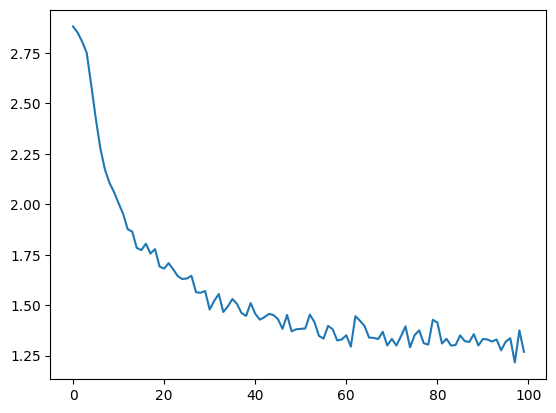

In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

plt.figure()
plt.plot(all_losses)

# 评估模型

为了直观展示模型性能，我们创建一个混淆矩阵，表示真实值及预测值的对应情况。

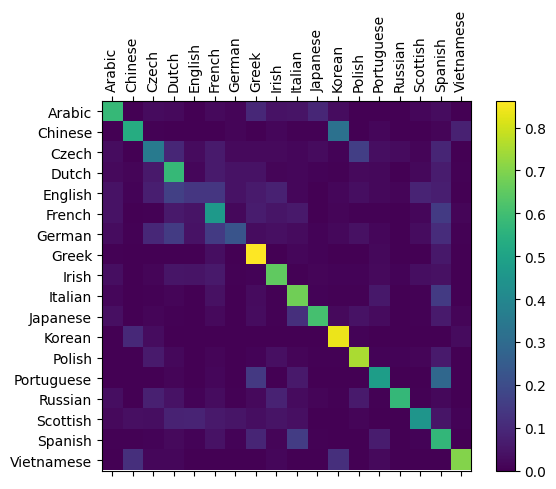

In [20]:
confusion = torch.zeros(n_categories, n_categories)
n_confusion = 10000

def evaluate(line_tensor):
    hidden = rnn.initHidden()
    for i in range(line_tensor.size()[0]):
        output, hidden = rnn(line_tensor[i], hidden)
    return output

# 遍历一系列样本，记录是否预测正确
for i in range(n_confusion):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output = evaluate(line_tensor)
    guess, guess_i = categoryFromOutput(output)
    category_i = all_categories.index(category)
    confusion[category_i][guess_i] += 1

for i in range(n_categories):
    confusion[i] = confusion[i] / confusion[i].sum()

fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(confusion.numpy())
fig.colorbar(cax)

ax.set_xticks(range(n_categories))
ax.set_yticks(range(n_categories))
ax.set_xticklabels(all_categories, rotation=90)
ax.set_yticklabels(all_categories)

plt.show()

最后，我们编写一个`predict`函数，用于预测用户输入的名字来源于哪种语言。

In [21]:
def predict(input_line, n_predictions=3):
    print('\n> %s' % input_line)
    with torch.no_grad():
        output = evaluate(lineToTensor(input_line))
        topv, topi = output.topk(n_predictions, 1, True)
        predictions = []
        for i in range(n_predictions):
            value = topv[0][i].item()
            category_index = topi[0][i].item()
            print('(%.2f) %s' % (value, all_categories[category_index]))
            predictions.append([value, all_categories[category_index]])

In [22]:
predict('Dovesky')


> Dovesky
(-0.34) Czech
(-1.57) Russian
(-3.34) Polish


In [23]:
predict('Satoshi')


> Satoshi
(-0.70) Japanese
(-1.27) Italian
(-2.39) Polish


In [24]:
predict('Zhang')


> Zhang
(-0.53) Korean
(-1.27) Chinese
(-2.44) Vietnamese


> 扩展1：上述实验过程没有进行训练集、测试集的划分，请你尝试划分训练、测试集，重新进行模型训练，并计算在测试集上的分类准确率。

> 扩展2：尝试使用`nn.RNN`、`nn.LSTM`等内置模块构建模型，并测试模型表现。